# Reviews as Moderators of Price Elasticity

This notebook analyzes how reviews and ratings affect price elasticity of demand.

**Research Questions:**
1. Do products with more reviews have different price elasticity than products with fewer/no reviews?
2. Do higher-rated products have different price elasticity than lower-rated products?

**Hypotheses:**
- H1: Products with more reviews have lower (less negative) price elasticity (trust reduces price sensitivity)
- H2: Higher-rated products have lower price elasticity (quality signal reduces price sensitivity)

**Methods:**
1. Heterogeneity analysis: Compare learned elasticities across review/rating groups
2. Ablation study: Compare NN with vs without review features

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


../venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths
DATA_DIR = Path('../data/processed')
TABLES_DIR = Path('../tables')
FIGURES_DIR = Path('../docs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Data and Model

In [3]:
# Load panel data
panel = pd.read_csv(DATA_DIR / 'panel.csv')
print(f"Panel shape: {panel.shape}")
print(f"\nSplit distribution:")
print(panel['split'].value_counts())

Panel shape: (17970, 43)

Split distribution:
split
train    11708
val       3392
test      2870
Name: count, dtype: int64


In [4]:
# Feature definitions
CONTEXT_FEATURES = [
    'year', 'month', 'weekofyear', 'week_sin', 'week_cos',
    'demand_lag_1', 'demand_lag_2', 'demand_roll_4',
    'price_lag_1', 'price_roll_4',
    'weeks_since_last_sale',
    'price_std', 'price_range'
]

PRODUCT_FEATURES = [
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_photos_qty', 'product_name_length', 'product_description_length'
]

REVIEW_FEATURES = ['sku_review_count', 'sku_review_mean', 'sku_share_low']

PRICE_FEATURE = 'r_clipped'
TARGET = 'y'

In [5]:
# Preprocess data (same as nn_improved.ipynb)
# Handle missing values
for col in ['demand_lag_1', 'demand_lag_2', 'demand_roll_4', 'price_lag_1', 'price_roll_4', 'weeks_since_last_sale']:
    panel[col] = panel[col].fillna(0)

for col in REVIEW_FEATURES:
    panel[col] = panel[col].fillna(0)

for col in PRODUCT_FEATURES:
    median_val = panel[col].median()
    panel[col] = panel[col].fillna(median_val)

# Encode categories and products
le_category = LabelEncoder()
panel['category_code'] = le_category.fit_transform(panel['product_category_name_english'].fillna('unknown'))
n_categories = len(le_category.classes_)

le_product = LabelEncoder()
panel['product_code'] = le_product.fit_transform(panel['product_id'])
n_products = len(le_product.classes_)

print(f"Number of categories: {n_categories}")
print(f"Number of products: {n_products}")

Number of categories: 56
Number of products: 1218


In [6]:
# Split data
train_df = panel[panel['split'] == 'train'].copy()
val_df = panel[panel['split'] == 'val'].copy()
test_df = panel[panel['split'] == 'test'].copy()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 11708, Val: 3392, Test: 2870


In [7]:
# Standardize features
scaler_context = StandardScaler()
scaler_product = StandardScaler()
scaler_review = StandardScaler()

train_context = scaler_context.fit_transform(train_df[CONTEXT_FEATURES])
train_product = scaler_product.fit_transform(train_df[PRODUCT_FEATURES])
train_review = scaler_review.fit_transform(train_df[REVIEW_FEATURES])

val_context = scaler_context.transform(val_df[CONTEXT_FEATURES])
val_product = scaler_product.transform(val_df[PRODUCT_FEATURES])
val_review = scaler_review.transform(val_df[REVIEW_FEATURES])

test_context = scaler_context.transform(test_df[CONTEXT_FEATURES])
test_product = scaler_product.transform(test_df[PRODUCT_FEATURES])
test_review = scaler_review.transform(test_df[REVIEW_FEATURES])

# Replace NaN with 0 after scaling
for arr in [train_context, train_product, train_review, val_context, val_product, val_review, test_context, test_product, test_review]:
    arr[:] = np.nan_to_num(arr, nan=0.0)

print("Features standardized.")

Features standardized.


## 2. Model Architecture (same as nn_improved.ipynb)

In [8]:
class DemandDataset(Dataset):
    def __init__(self, df, context_arr, product_arr, review_arr):
        self.context = torch.FloatTensor(context_arr)
        self.product = torch.FloatTensor(product_arr)
        self.review = torch.FloatTensor(review_arr)
        self.r = torch.FloatTensor(df[PRICE_FEATURE].values)
        self.log_r = torch.log(self.r)
        self.category = torch.LongTensor(df['category_code'].values)
        self.product_id = torch.LongTensor(df['product_code'].values)
        self.y = torch.FloatTensor(df[TARGET].values)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return {
            'context': self.context[idx],
            'product': self.product[idx],
            'review': self.review[idx],
            'r': self.r[idx],
            'log_r': self.log_r[idx],
            'category': self.category[idx],
            'product_id': self.product_id[idx],
            'y': self.y[idx]
        }

In [9]:
class ContextEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, x):
        return self.net(x)


class MonotonicPriceEncoder(nn.Module):
    def __init__(self, z_dim, num_basis=20, hidden_dim=128):
        super().__init__()
        self.num_basis = num_basis
        self.z_encoder = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3 * num_basis)
        )
        
    def forward(self, log_r, z, return_at_ref=False):
        B = log_r.shape[0]
        params = self.z_encoder(z)
        params = params.view(B, self.num_basis, 3)
        
        a_raw = params[:, :, 0]
        b = params[:, :, 1]
        w_raw = params[:, :, 2]
        
        a = F.softplus(a_raw) + 0.1
        w = -F.softplus(w_raw)
        
        log_r_expanded = log_r.unsqueeze(1)
        sigmoid_input = a * log_r_expanded + b
        g = (w * torch.sigmoid(sigmoid_input)).sum(dim=1, keepdim=True)
        
        if return_at_ref:
            sigmoid_input_ref = b
            g_ref = (w * torch.sigmoid(sigmoid_input_ref)).sum(dim=1, keepdim=True)
            return g, g_ref
        
        return g


class ImprovedTwoHeadModel(nn.Module):
    def __init__(self, 
                 context_dim,
                 product_dim,
                 review_dim,
                 n_categories,
                 n_products,
                 category_embedding_dim=16,
                 product_embedding_dim=16,
                 context_hidden=256,
                 price_hidden=128,
                 num_basis=20,
                 dropout=0.15):
        super().__init__()
        
        self.category_embedding = nn.Embedding(n_categories, category_embedding_dim)
        self.product_embedding = nn.Embedding(n_products, product_embedding_dim)
        
        context_input_dim = context_dim + category_embedding_dim + product_embedding_dim
        self.context_encoder = ContextEncoder(
            input_dim=context_input_dim,
            hidden_dim=context_hidden,
            dropout=dropout
        )
        
        z_dim = category_embedding_dim + product_embedding_dim + product_dim + review_dim
        self.price_encoder = MonotonicPriceEncoder(
            z_dim=z_dim,
            num_basis=num_basis,
            hidden_dim=price_hidden
        )
        
        self.n_products = n_products
        self.product_embedding_dim = product_embedding_dim
        self.review_dim = review_dim
    
    def forward(self, batch):
        cat_emb = self.category_embedding(batch['category'])
        prod_emb = self.product_embedding(batch['product_id'])
        
        context_input = torch.cat([batch['context'], cat_emb, prod_emb], dim=1)
        log_demand_base = self.context_encoder(context_input)
        
        z = torch.cat([cat_emb, prod_emb, batch['product'], batch['review']], dim=1)
        
        g_r, g_ref = self.price_encoder(batch['log_r'], z, return_at_ref=True)
        log_mul = g_r - g_ref
        
        log_demand_pred = log_demand_base + log_mul
        
        return log_demand_pred.squeeze(1)

In [10]:
# Load saved model
checkpoint = torch.load(DATA_DIR / 'improved_nn_model.pt', map_location=device, weights_only=False)
config = checkpoint['config']

model = ImprovedTwoHeadModel(**config)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"Model loaded. Config:")
for k, v in config.items():
    print(f"  {k}: {v}")

print(f"\nTest metrics from training:")
for k, v in checkpoint['test_metrics'].items():
    print(f"  {k}: {v:.4f}")

Model loaded. Config:
  context_dim: 13
  product_dim: 7
  review_dim: 3
  n_categories: 56
  n_products: 1218
  category_embedding_dim: 16
  product_embedding_dim: 16
  context_hidden: 256
  price_hidden: 128
  num_basis: 20
  dropout: 0.15

Test metrics from training:
  mse: 0.2090
  mae: 0.3286
  rmse: 0.4572
  r2: -0.1941
  corr_mse: 0.1081


## 3. Analyze Review Distribution

In [11]:
# Get product-level review stats (take max since they're cumulative)
product_reviews = panel.groupby('product_id').agg({
    'sku_review_count': 'max',
    'sku_review_mean': 'max',
    'sku_share_low': 'max'
}).reset_index()

print(f"Total products: {len(product_reviews)}")
print(f"\nReview count distribution:")
print(product_reviews['sku_review_count'].describe())

Total products: 1218

Review count distribution:
count    1218.000000
mean       25.907225
std        43.464967
min         0.000000
25%         9.000000
50%        14.000000
75%        26.000000
max       516.000000
Name: sku_review_count, dtype: float64


In [12]:
# Create review count groups
# Create quartile-based review groups (consistent with thesis methodology)
# Quartile boundaries: Q1: 0-6, Q2: 7-12, Q3: 13-24, Q4: 25+
def categorize_review_count(count):
    """Categorize review count into quartiles."""
    if count <= 6:
        return 'Q1 (0-6)'
    elif count <= 12:
        return 'Q2 (7-12)'
    elif count <= 24:
        return 'Q3 (13-24)'
    else:
        return 'Q4 (25+)'

product_reviews['review_group'] = product_reviews['sku_review_count'].apply(categorize_review_count)

print("\nReview count quartiles:")
print(product_reviews['review_group'].value_counts().sort_index())


Review count quartiles:
review_group
Q1 (0-6)      199
Q2 (7-12)     345
Q3 (13-24)    356
Q4 (25+)      318
Name: count, dtype: int64


In [13]:
# Create rating groups (only for products with reviews)
def categorize_rating(row):
    if row['sku_review_count'] == 0 or pd.isna(row['sku_review_mean']):
        return 'No rating'
    elif row['sku_review_mean'] < 3.5:
        return 'Low (<3.5)'
    elif row['sku_review_mean'] <= 4.5:
        return 'Medium (3.5-4.5)'
    else:
        return 'High (>4.5)'

product_reviews['rating_group'] = product_reviews.apply(categorize_rating, axis=1)

print("\nRating groups:")
print(product_reviews['rating_group'].value_counts())


Rating groups:
rating_group
High (>4.5)         617
Medium (3.5-4.5)    496
Low (<3.5)           60
No rating            45
Name: count, dtype: int64


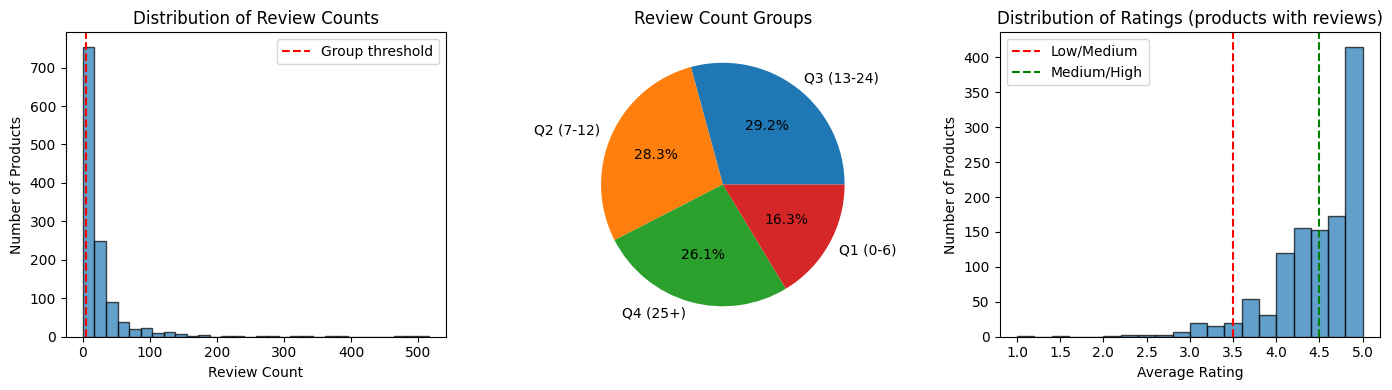

In [14]:
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Review count histogram
axes[0].hist(product_reviews['sku_review_count'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Review Count')
axes[0].set_ylabel('Number of Products')
axes[0].set_title('Distribution of Review Counts')
axes[0].axvline(x=5, color='red', linestyle='--', label='Group threshold')
axes[0].legend()

# Review groups pie chart
review_counts = product_reviews['review_group'].value_counts()
axes[1].pie(review_counts.values, labels=review_counts.index, autopct='%1.1f%%')
axes[1].set_title('Review Count Groups')

# Rating distribution
rated = product_reviews[product_reviews['sku_review_count'] > 0]
axes[2].hist(rated['sku_review_mean'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[2].axvline(x=3.5, color='red', linestyle='--', label='Low/Medium')
axes[2].axvline(x=4.5, color='green', linestyle='--', label='Medium/High')
axes[2].set_xlabel('Average Rating')
axes[2].set_ylabel('Number of Products')
axes[2].set_title('Distribution of Ratings (products with reviews)')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'review_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Compute Elasticities for All Products

In [15]:
def compute_product_elasticities(model, panel_df, scaler_product, scaler_review, device):
    """Compute elasticity at r=1 for each product."""
    model.eval()
    
    # Get unique products from test set
    test_products = panel_df[panel_df['split'] == 'test'].copy()
    unique_products = test_products['product_code'].unique()
    
    r_grid = torch.linspace(0.8, 1.2, 50).to(device)
    log_r_grid = torch.log(r_grid)
    
    results = []
    
    for prod_code in tqdm(unique_products, desc="Computing elasticities"):
        mask = test_products['product_code'] == prod_code
        if mask.sum() == 0:
            continue
            
        # Get first observation for this product
        idx = np.where(mask)[0][0]
        row = test_products.iloc[idx]
        
        # Get embeddings
        cat_idx = int(row['category_code'])
        cat_emb = model.category_embedding(torch.tensor([cat_idx]).to(device))
        prod_emb = model.product_embedding(torch.tensor([prod_code]).to(device))
        
        # Build z
        prod_feat = torch.FloatTensor(
            scaler_product.transform(test_products.iloc[[idx]][PRODUCT_FEATURES])
        ).to(device)
        review_feat = torch.FloatTensor(
            scaler_review.transform(test_products.iloc[[idx]][REVIEW_FEATURES])
        ).to(device)
        
        z = torch.cat([cat_emb, prod_emb, prod_feat, review_feat], dim=1)
        
        # Get demand curve
        with torch.no_grad():
            z_expanded = z.expand(len(r_grid), -1)
            g_r, g_ref = model.price_encoder(log_r_grid, z_expanded, return_at_ref=True)
            g_values = (g_r - g_ref).squeeze(1).cpu().numpy()
        
        # Estimate elasticity at r=1 using finite differences
        r1_idx = np.argmin(np.abs(r_grid.cpu().numpy() - 1.0))
        if r1_idx > 0 and r1_idx < len(g_values) - 1:
            dr = log_r_grid[r1_idx+1].item() - log_r_grid[r1_idx-1].item()
            dg = g_values[r1_idx+1] - g_values[r1_idx-1]
            elasticity = dg / dr
        else:
            elasticity = np.nan
        
        results.append({
            'product_code': prod_code,
            'product_id': row['product_id'],
            'category': row['product_category_name_english'],
            'elasticity': elasticity,
            'review_count': row['sku_review_count'],
            'review_mean': row['sku_review_mean'],
            'share_low': row['sku_share_low']
        })
    
    return pd.DataFrame(results)

In [16]:
# Compute elasticities
elasticities_df = compute_product_elasticities(model, panel, scaler_product, scaler_review, device)

print(f"\nComputed elasticities for {len(elasticities_df)} products")
print(f"\nElasticity distribution:")
print(elasticities_df['elasticity'].describe())

Computing elasticities:   0%|          | 0/739 [00:00<?, ?it/s]

Computing elasticities:   0%|          | 1/739 [00:00<07:57,  1.55it/s]

Computing elasticities:   5%|▍         | 34/739 [00:00<00:11, 60.83it/s]

Computing elasticities:   7%|▋         | 54/739 [00:00<00:07, 87.10it/s]

Computing elasticities:  12%|█▏        | 85/739 [00:00<00:04, 136.56it/s]

...

Computing elasticities:  89%|████████▉ | 656/739 [00:02<00:00, 350.38it/s]

Computing elasticities:  94%|█████████▎| 692/739 [00:02<00:00, 351.33it/s]

Computing elasticities:  99%|█████████▊| 728/739 [00:02<00:00, 351.69it/s]

Computing elasticities: 100%|██████████| 739/739 [00:02<00:00, 261.78it/s]


Computed elasticities for 739 products

Elasticity distribution:
count    739.000000
mean      -0.983693
std        1.420454
min       -8.510820
25%       -1.319296
50%       -0.399093
75%       -0.088604
max       -0.000062
Name: elasticity, dtype: float64


In [17]:
# Add review groups
elasticities_df['review_group'] = elasticities_df['review_count'].apply(categorize_review_count)

def get_rating_group(row):
    if row['review_count'] == 0 or pd.isna(row['review_mean']):
        return 'No rating'
    elif row['review_mean'] < 3.5:
        return 'Low (<3.5)'
    elif row['review_mean'] <= 4.5:
        return 'Medium (3.5-4.5)'
    else:
        return 'High (>4.5)'

elasticities_df['rating_group'] = elasticities_df.apply(get_rating_group, axis=1)

print("\nElasticities by review group:")
print(elasticities_df.groupby('review_group')['elasticity'].agg(['count', 'mean', 'median', 'std']))


Elasticities by review group:
              count      mean    median       std
review_group                                     
Q1 (0-6)        186 -0.574806 -0.194529  1.010519
Q2 (7-12)       187 -0.729675 -0.252382  1.107311
Q3 (13-24)      188 -0.953200 -0.486454  1.282529
Q4 (25+)        178 -1.710025 -1.059671  1.882487


## 5. Heterogeneity Analysis: Review Count Groups

In [18]:
# Statistical test: Kruskal-Wallis (non-parametric ANOVA)
from scipy import stats

# Kruskal-Wallis test across quartile groups
quartile_order = ['Q1 (0-6)', 'Q2 (7-12)', 'Q3 (13-24)', 'Q4 (25+)']
quartile_groups = []
for q in quartile_order:
    group_data = elasticities_df[elasticities_df['review_group'] == q]['elasticity'].dropna().tolist()
    quartile_groups.append(group_data)

# Filter out empty groups
quartile_groups = [g for g in quartile_groups if len(g) > 0]

if len(quartile_groups) >= 2:
    stat, p_value = stats.kruskal(*quartile_groups)
    print(f"Kruskal-Wallis test (Review Count Groups):")
    print(f"  H-statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Significant at 0.05: {'Yes' if p_value < 0.05 else 'No'}")
else:
    print("Not enough data in some groups for statistical test")

Kruskal-Wallis test (Review Count Groups):
  H-statistic: 79.7756
  p-value: 0.0000
  Significant at 0.05: Yes


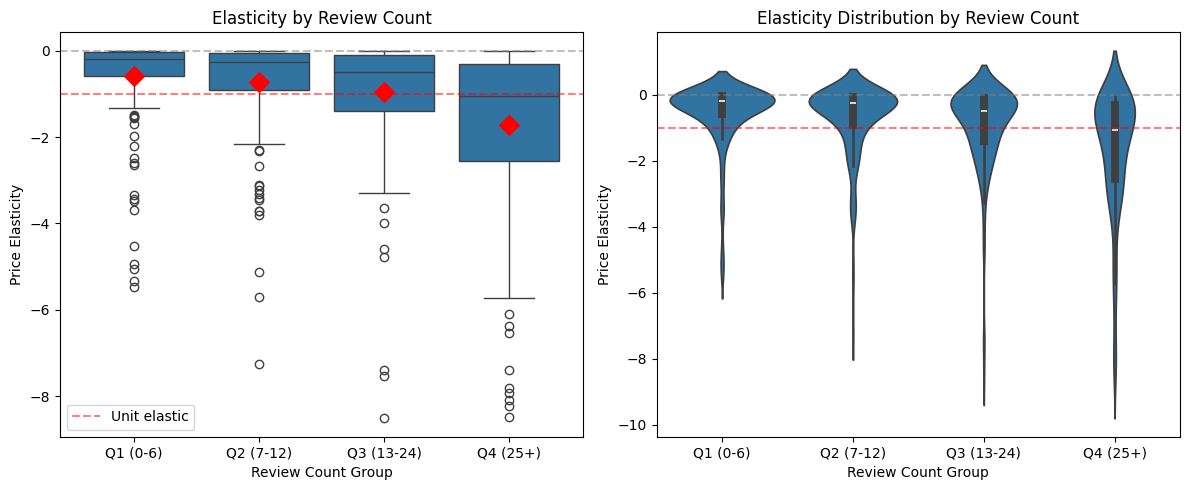

In [19]:
# Visualize elasticity by review count groups
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
order = ['Q1 (0-6)', 'Q2 (7-12)', 'Q3 (13-24)', 'Q4 (25+)']
valid_df = elasticities_df[elasticities_df['elasticity'].notna()]

sns.boxplot(data=valid_df, x='review_group', y='elasticity', order=order, ax=axes[0])
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=-1, color='red', linestyle='--', alpha=0.5, label='Unit elastic')
axes[0].set_xlabel('Review Count Group')
axes[0].set_ylabel('Price Elasticity')
axes[0].set_title('Elasticity by Review Count')
axes[0].legend()

# Add means
means = valid_df.groupby('review_group')['elasticity'].mean()
for i, grp in enumerate(order):
    if grp in means.index:
        axes[0].scatter(i, means[grp], color='red', s=100, zorder=5, marker='D', label='Mean' if i == 0 else '')

# Violin plot
sns.violinplot(data=valid_df, x='review_group', y='elasticity', order=order, ax=axes[1])
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(y=-1, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Review Count Group')
axes[1].set_ylabel('Price Elasticity')
axes[1].set_title('Elasticity Distribution by Review Count')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'elasticity_by_review_count.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Heterogeneity Analysis: Rating Groups

In [20]:
print("\nElasticities by rating group:")
print(elasticities_df.groupby('rating_group')['elasticity'].agg(['count', 'mean', 'median', 'std']))


Elasticities by rating group:
                  count      mean    median       std
rating_group                                         
High (>4.5)         129 -0.842551 -0.336383  1.239038
Low (<3.5)           89 -1.243641 -0.568928  1.676372
Medium (3.5-4.5)    477 -1.042037 -0.429808  1.450980
No rating            44 -0.239185 -0.075224  0.444818


In [21]:
# Statistical test for rating groups (exclude 'No rating')
rated_df = elasticities_df[elasticities_df['rating_group'] != 'No rating'].copy()

groups_rating = rated_df.groupby('rating_group')['elasticity'].apply(list)
group_low = [x for x in groups_rating.get('Low (<3.5)', []) if not np.isnan(x)]
group_med = [x for x in groups_rating.get('Medium (3.5-4.5)', []) if not np.isnan(x)]
group_high = [x for x in groups_rating.get('High (>4.5)', []) if not np.isnan(x)]

valid_groups = [g for g in [group_low, group_med, group_high] if len(g) > 0]
if len(valid_groups) >= 2:
    stat, p_value = stats.kruskal(*valid_groups)
    print(f"\nKruskal-Wallis test (Rating Groups):")
    print(f"  H-statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Significant at 0.05: {'Yes' if p_value < 0.05 else 'No'}")
else:
    print("Not enough groups for statistical test")


Kruskal-Wallis test (Rating Groups):
  H-statistic: 4.9477
  p-value: 0.0843
  Significant at 0.05: No


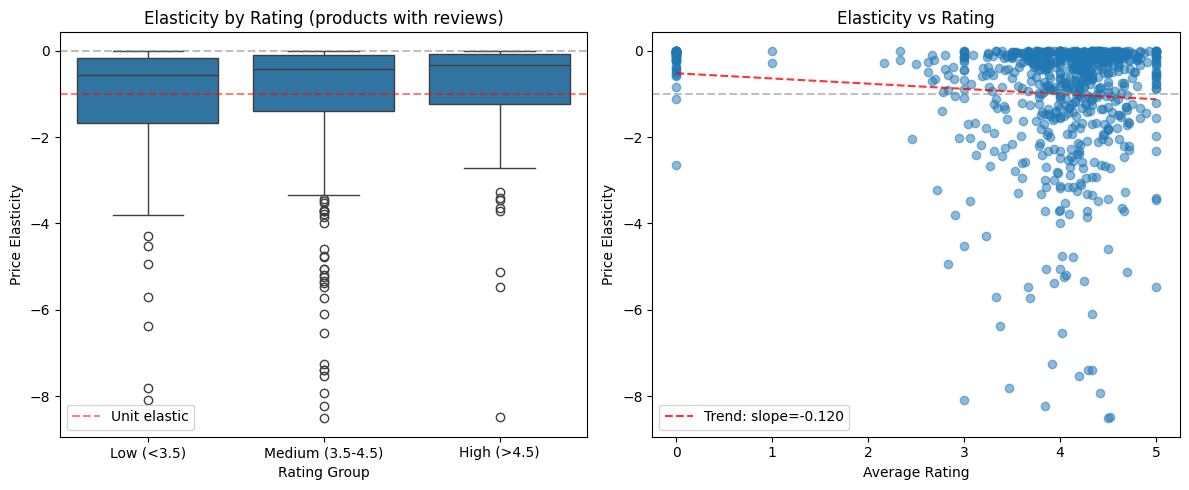

In [22]:
# Visualize elasticity by rating groups
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Only products with ratings
rated_valid = rated_df[rated_df['elasticity'].notna()]
order_rating = ['Low (<3.5)', 'Medium (3.5-4.5)', 'High (>4.5)']

if len(rated_valid) > 0:
    sns.boxplot(data=rated_valid, x='rating_group', y='elasticity', order=order_rating, ax=axes[0])
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(y=-1, color='red', linestyle='--', alpha=0.5, label='Unit elastic')
    axes[0].set_xlabel('Rating Group')
    axes[0].set_ylabel('Price Elasticity')
    axes[0].set_title('Elasticity by Rating (products with reviews)')
    axes[0].legend()

    # Scatter plot: rating vs elasticity
    scatter_df = elasticities_df[(elasticities_df['review_mean'].notna()) & (elasticities_df['elasticity'].notna())]
    axes[1].scatter(scatter_df['review_mean'], scatter_df['elasticity'], alpha=0.5)
    
    # Add trend line
    if len(scatter_df) > 2:
        z = np.polyfit(scatter_df['review_mean'], scatter_df['elasticity'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(scatter_df['review_mean'].min(), scatter_df['review_mean'].max(), 100)
        axes[1].plot(x_line, p(x_line), 'r--', alpha=0.8, label=f'Trend: slope={z[0]:.3f}')
    
    axes[1].axhline(y=-1, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Average Rating')
    axes[1].set_ylabel('Price Elasticity')
    axes[1].set_title('Elasticity vs Rating')
    axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'elasticity_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Demand Curves by Review Group

In [23]:
def plot_demand_curves_by_group(model, panel_df, elasticities_df, scaler_product, scaler_review, device, 
                                 group_col='review_group', n_per_group=3):
    """Plot example demand curves for each group."""
    model.eval()
    test_products = panel_df[panel_df['split'] == 'test'].copy()
    
    r_grid = torch.linspace(0.8, 1.2, 100).to(device)
    log_r_grid = torch.log(r_grid)
    r_values = r_grid.cpu().numpy()
    
    groups = elasticities_df[group_col].unique()
    groups = [g for g in groups if g != 'No rating']  # Exclude 'No rating' for cleaner plots
    
    fig, axes = plt.subplots(1, len(groups), figsize=(5*len(groups), 4))
    if len(groups) == 1:
        axes = [axes]
    
    for ax, group in zip(axes, groups):
        group_products = elasticities_df[elasticities_df[group_col] == group]
        
        # Sample products
        sample_products = group_products.sample(min(n_per_group, len(group_products)), random_state=42)
        
        for _, row in sample_products.iterrows():
            prod_code = row['product_code']
            mask = test_products['product_code'] == prod_code
            if mask.sum() == 0:
                continue
            
            idx = np.where(mask)[0][0]
            obs = test_products.iloc[idx]
            
            # Get embeddings
            cat_idx = int(obs['category_code'])
            cat_emb = model.category_embedding(torch.tensor([cat_idx]).to(device))
            prod_emb = model.product_embedding(torch.tensor([prod_code]).to(device))
            
            # Build z
            prod_feat = torch.FloatTensor(
                scaler_product.transform(test_products.iloc[[idx]][PRODUCT_FEATURES])
            ).to(device)
            review_feat = torch.FloatTensor(
                scaler_review.transform(test_products.iloc[[idx]][REVIEW_FEATURES])
            ).to(device)
            
            z = torch.cat([cat_emb, prod_emb, prod_feat, review_feat], dim=1)
            
            # Get demand curve
            with torch.no_grad():
                z_expanded = z.expand(len(r_grid), -1)
                g_r, g_ref = model.price_encoder(log_r_grid, z_expanded, return_at_ref=True)
                g_values = (g_r - g_ref).squeeze(1).cpu().numpy()
            
            # Convert to demand multiplier E(r)
            e_values = np.exp(g_values)
            
            ax.plot(r_values, e_values, alpha=0.7, label=f'ε={row["elasticity"]:.2f}')
        
        ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Relative Price (r = P/P₀)')
        ax.set_ylabel('Demand Multiplier E(r)')
        ax.set_title(f'{group}')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_xlim(0.8, 1.2)
    
    plt.tight_layout()
    return fig

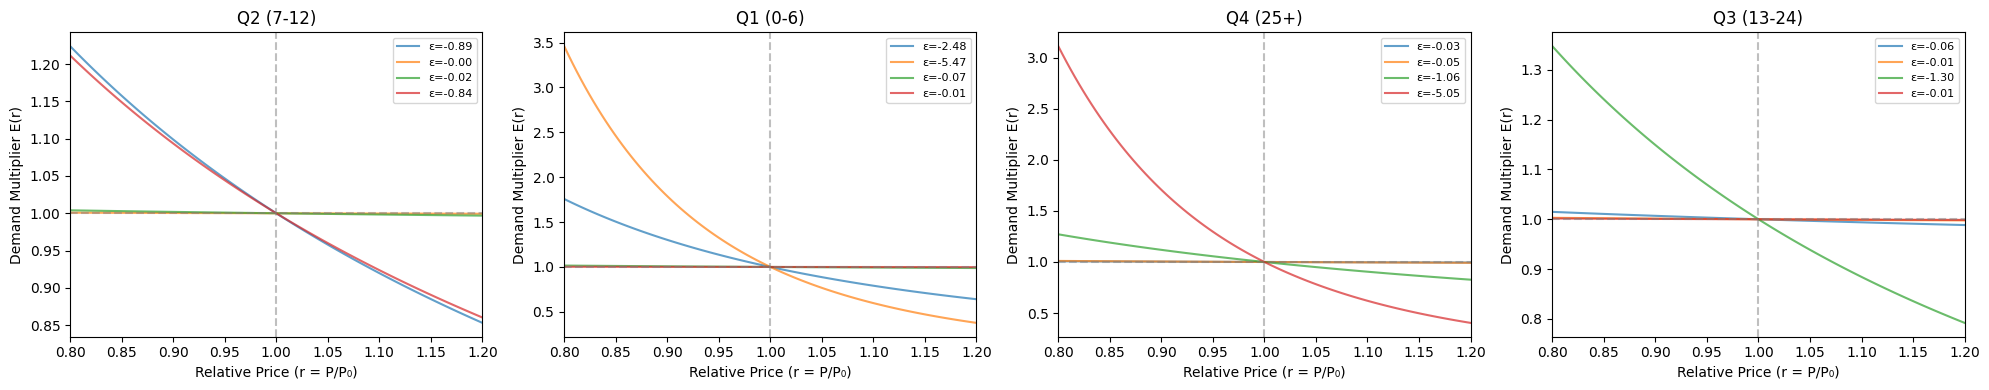

In [24]:
# Plot demand curves by review count
fig = plot_demand_curves_by_group(model, panel, elasticities_df, scaler_product, scaler_review, device,
                                   group_col='review_group', n_per_group=4)
plt.savefig(FIGURES_DIR / 'demand_curves_by_review_count.png', dpi=150, bbox_inches='tight')
plt.show()

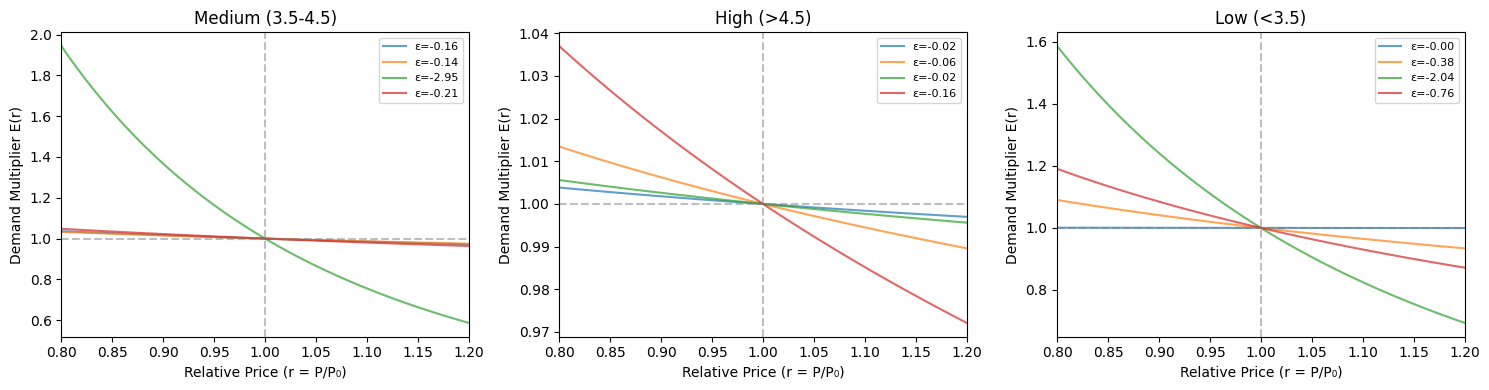

In [25]:
# Plot demand curves by rating
fig = plot_demand_curves_by_group(model, panel, elasticities_df, scaler_product, scaler_review, device,
                                   group_col='rating_group', n_per_group=4)
plt.savefig(FIGURES_DIR / 'demand_curves_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Ablation Study: Model Without Review Features

In [26]:
# Create model WITHOUT review features
class TwoHeadModelNoReviews(nn.Module):
    """Two-head model without review features in price encoder."""
    
    def __init__(self, 
                 context_dim,
                 product_dim,
                 n_categories,
                 n_products,
                 category_embedding_dim=16,
                 product_embedding_dim=16,
                 context_hidden=256,
                 price_hidden=128,
                 num_basis=20,
                 dropout=0.15):
        super().__init__()
        
        self.category_embedding = nn.Embedding(n_categories, category_embedding_dim)
        self.product_embedding = nn.Embedding(n_products, product_embedding_dim)
        
        # Context encoder (same as before)
        context_input_dim = context_dim + category_embedding_dim + product_embedding_dim
        self.context_encoder = ContextEncoder(
            input_dim=context_input_dim,
            hidden_dim=context_hidden,
            dropout=dropout
        )
        
        # Price encoder WITHOUT review features
        z_dim = category_embedding_dim + product_embedding_dim + product_dim  # NO review_dim!
        self.price_encoder = MonotonicPriceEncoder(
            z_dim=z_dim,
            num_basis=num_basis,
            hidden_dim=price_hidden
        )
    
    def forward(self, batch):
        cat_emb = self.category_embedding(batch['category'])
        prod_emb = self.product_embedding(batch['product_id'])
        
        context_input = torch.cat([batch['context'], cat_emb, prod_emb], dim=1)
        log_demand_base = self.context_encoder(context_input)
        
        # z WITHOUT review features
        z = torch.cat([cat_emb, prod_emb, batch['product']], dim=1)
        
        g_r, g_ref = self.price_encoder(batch['log_r'], z, return_at_ref=True)
        log_mul = g_r - g_ref
        
        log_demand_pred = log_demand_base + log_mul
        
        return log_demand_pred.squeeze(1)

In [27]:
# Create datasets and loaders
train_dataset = DemandDataset(train_df, train_context, train_product, train_review)
val_dataset = DemandDataset(val_df, val_context, val_product, val_review)
test_dataset = DemandDataset(test_df, test_context, test_product, test_review)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")

Train batches: 46


In [28]:
def compute_corr_mse(y_true, y_pred, groups):
    """Compute group-corrected MSE."""
    df = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'group': groups
    })
    
    def group_corr_mse(g):
        if len(g) < 2:
            return 0, 0
        y_t = g['y_true'].values
        y_p = g['y_pred'].values
        y_t_centered = y_t - y_t.mean()
        y_p_centered = y_p - y_p.mean()
        mse = ((y_t_centered - y_p_centered) ** 2).mean()
        return mse * len(g), len(g)
    
    results = df.groupby('group').apply(group_corr_mse)
    total_mse = sum(r[0] for r in results)
    total_weight = sum(r[1] for r in results)
    
    return total_mse / total_weight if total_weight > 0 else 0


def evaluate_model(model, loader, df, device):
    """Evaluate model on a dataset."""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            preds = model(batch)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(batch['y'].cpu().numpy())
    
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr_mse = compute_corr_mse(y_true, y_pred, df['product_id'].values)
    
    return {
        'mse': mse,
        'r2': r2,
        'corr_mse': corr_mse
    }, y_pred

In [29]:
def train_model_simple(model, train_loader, val_loader, train_df, val_df, 
                       device, epochs=150, lr=5e-4, weight_decay=1e-5, 
                       patience=30, grad_clip=1.0, verbose=True):
    """Train model with early stopping."""
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    
    best_val_corr_mse = float('inf')
    best_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            optimizer.zero_grad()
            preds = model(batch)
            loss = criterion(preds, batch['y'])
            loss.backward()
            
            if grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            train_losses.append(loss.item())
        
        scheduler.step()
        avg_train_loss = np.mean(train_losses)
        
        # Validation
        val_metrics, _ = evaluate_model(model, val_loader, val_df, device)
        
        # Early stopping
        if val_metrics['corr_mse'] < best_val_corr_mse:
            best_val_corr_mse = val_metrics['corr_mse']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}: train_loss={avg_train_loss:.4f}, "
                  f"val_corr_mse={val_metrics['corr_mse']:.4f} (best={best_val_corr_mse:.4f})")
        
        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    
    return model, best_val_corr_mse

In [30]:
# Train model WITHOUT reviews
config_no_reviews = {
    'context_dim': len(CONTEXT_FEATURES),
    'product_dim': len(PRODUCT_FEATURES),
    'n_categories': n_categories,
    'n_products': n_products,
    'category_embedding_dim': 16,
    'product_embedding_dim': 16,
    'context_hidden': 256,
    'price_hidden': 128,
    'num_basis': 20,
    'dropout': 0.15
}

model_no_reviews = TwoHeadModelNoReviews(**config_no_reviews)
n_params_no_rev = sum(p.numel() for p in model_no_reviews.parameters())
print(f"Model WITHOUT reviews: {n_params_no_rev:,} parameters")

print("\nTraining model WITHOUT review features...")
model_no_reviews, best_val_no_rev = train_model_simple(
    model_no_reviews, train_loader, val_loader, train_df, val_df, device,
    epochs=150, lr=5e-4, patience=30, verbose=True
)

Model WITHOUT reviews: 82,461 parameters

Training model WITHOUT review features...


Epoch 20/150: train_loss=0.1218, val_corr_mse=0.1060 (best=0.1058)


Epoch 40/150: train_loss=0.1055, val_corr_mse=0.1040 (best=0.1036)


Epoch 60/150: train_loss=0.0935, val_corr_mse=0.1035 (best=0.1034)


Early stopping at epoch 79


In [31]:
# Evaluate on test set
test_metrics_no_rev, _ = evaluate_model(model_no_reviews, test_loader, test_df, device)

print("\n" + "="*60)
print("ABLATION STUDY RESULTS")
print("="*60)

print(f"\n{'Model':<30} {'Test corr_mse':>12} {'R²':>10}")
print("-" * 54)
print(f"{'With reviews (original)':<30} {checkpoint['test_metrics']['corr_mse']:>12.4f} {checkpoint['test_metrics']['r2']:>10.4f}")
print(f"{'WITHOUT reviews (ablation)':<30} {test_metrics_no_rev['corr_mse']:>12.4f} {test_metrics_no_rev['r2']:>10.4f}")

diff_pct = (test_metrics_no_rev['corr_mse'] - checkpoint['test_metrics']['corr_mse']) / checkpoint['test_metrics']['corr_mse'] * 100
print(f"\nDifference: {diff_pct:+.2f}%")
print(f"Reviews contribution: {'Positive' if diff_pct > 0 else 'Negative'} (removing reviews {'worsens' if diff_pct > 0 else 'improves'} performance)")


ABLATION STUDY RESULTS

Model                          Test corr_mse         R²
------------------------------------------------------
With reviews (original)              0.1081    -0.1941
WITHOUT reviews (ablation)           0.1070    -0.0716

Difference: -0.94%
Reviews contribution: Negative (removing reviews improves performance)


## 9. Summary Tables

In [32]:
# Summary table: Elasticity by review count
summary_review_count = elasticities_df.groupby('review_group').agg({
    'elasticity': ['count', 'mean', 'median', 'std']
}).round(4)
summary_review_count.columns = ['N Products', 'Mean ε', 'Median ε', 'Std ε']
summary_review_count = summary_review_count.reindex(['Q1 (0-6)', 'Q2 (7-12)', 'Q3 (13-24)', 'Q4 (25+)'])

print("\n" + "="*60)
print("TABLE: Elasticity by Review Count")
print("="*60)
print(summary_review_count.to_string())

# Save to CSV
summary_review_count.to_csv(TABLES_DIR / 'elasticity_by_review_count.csv')


TABLE: Elasticity by Review Count
              N Products  Mean ε  Median ε   Std ε
review_group                                      
Q1 (0-6)             186 -0.5748   -0.1945  1.0105
Q2 (7-12)            187 -0.7297   -0.2524  1.1073
Q3 (13-24)           188 -0.9532   -0.4865  1.2825
Q4 (25+)             178 -1.7100   -1.0597  1.8825


In [33]:
# Summary table: Elasticity by rating
summary_rating = elasticities_df[elasticities_df['rating_group'] != 'No rating'].groupby('rating_group').agg({
    'elasticity': ['count', 'mean', 'median', 'std']
}).round(4)
summary_rating.columns = ['N Products', 'Mean ε', 'Median ε', 'Std ε']
summary_rating = summary_rating.reindex(['Low (<3.5)', 'Medium (3.5-4.5)', 'High (>4.5)'])

print("\n" + "="*60)
print("TABLE: Elasticity by Rating (products with reviews)")
print("="*60)
print(summary_rating.to_string())

# Save to CSV
summary_rating.to_csv(TABLES_DIR / 'elasticity_by_rating.csv')


TABLE: Elasticity by Rating (products with reviews)
                  N Products  Mean ε  Median ε   Std ε
rating_group                                          
Low (<3.5)                89 -1.2436   -0.5689  1.6764
Medium (3.5-4.5)         477 -1.0420   -0.4298  1.4510
High (>4.5)              129 -0.8426   -0.3364  1.2390


In [34]:
# Ablation study table
ablation_results = pd.DataFrame({
    'Model': ['With reviews', 'Without reviews'],
    'Parameters': [sum(p.numel() for p in model.parameters()), n_params_no_rev],
    'Test corr_mse': [checkpoint['test_metrics']['corr_mse'], test_metrics_no_rev['corr_mse']],
    'Test R²': [checkpoint['test_metrics']['r2'], test_metrics_no_rev['r2']]
})
ablation_results['Δ corr_mse'] = ablation_results['Test corr_mse'] - ablation_results['Test corr_mse'].iloc[0]

print("\n" + "="*60)
print("TABLE: Ablation Study Results")
print("="*60)
print(ablation_results.to_string(index=False))

ablation_results.to_csv(TABLES_DIR / 'ablation_reviews.csv', index=False)


TABLE: Ablation Study Results
          Model  Parameters  Test corr_mse   Test R²  Δ corr_mse
   With reviews       82845       0.108062 -0.194072    0.000000
Without reviews       82461       0.107047 -0.071563   -0.001015


## 10. Key Findings

In [35]:
print("\n" + "="*70)
print("KEY FINDINGS: Reviews as Moderators of Price Elasticity")
print("="*70)

# Get summary stats
mean_by_group = elasticities_df.groupby('review_group')['elasticity'].mean()

print(f"\n1. HETEROGENEITY BY REVIEW COUNT")
for q in ['Q1 (0-6)', 'Q2 (7-12)', 'Q3 (13-24)', 'Q4 (25+)']:
    if q in mean_by_group.index:
        print(f"   - {q}: mean ε = {mean_by_group[q]:.3f}")

# Interpretation
q1_mean = mean_by_group.get('Q1 (0-6)', 0)
q4_mean = mean_by_group.get('Q4 (25+)', 0)
if q1_mean > q4_mean:  # Q1 less negative than Q4
    print(f"   → Products with MORE reviews have MORE negative elasticity")
    print(f"   → This contradicts H1: reviews increase price sensitivity")
else:
    print(f"   → Products with MORE reviews have LESS negative elasticity")
    print(f"   → This supports H1: reviews reduce price sensitivity")

print(f"\n2. HETEROGENEITY BY RATING")
mean_by_rating = elasticities_df[elasticities_df['rating_group'] != 'No rating'].groupby('rating_group')['elasticity'].mean()
for rating in ['Low (<3.5)', 'Medium (3.5-4.5)', 'High (>4.5)']:
    if rating in mean_by_rating.index:
        print(f"   - {rating}: mean ε = {mean_by_rating[rating]:.3f}")

print(f"\n3. ABLATION STUDY")
print(f"   - Model WITH reviews: corr_mse = {checkpoint['test_metrics']['corr_mse']:.4f}")
print(f"   - Model WITHOUT reviews: corr_mse = {test_metrics_no_rev['corr_mse']:.4f}")
print(f"   - Difference: {diff_pct:+.2f}%")
if diff_pct > 0:
    print(f"   → Removing reviews WORSENS model performance")
    print(f"   → Reviews contain useful information for demand prediction")
else:
    print(f"   → Removing reviews IMPROVES model performance")
    print(f"   → Reviews may not add value in elasticity head")


KEY FINDINGS: Reviews as Moderators of Price Elasticity

1. HETEROGENEITY BY REVIEW COUNT
   - Q1 (0-6): mean ε = -0.575
   - Q2 (7-12): mean ε = -0.730
   - Q3 (13-24): mean ε = -0.953
   - Q4 (25+): mean ε = -1.710
   → Products with MORE reviews have MORE negative elasticity
   → This contradicts H1: reviews increase price sensitivity

2. HETEROGENEITY BY RATING
   - Low (<3.5): mean ε = -1.244
   - Medium (3.5-4.5): mean ε = -1.042
   - High (>4.5): mean ε = -0.843

3. ABLATION STUDY
   - Model WITH reviews: corr_mse = 0.1081
   - Model WITHOUT reviews: corr_mse = 0.1070
   - Difference: -0.94%
   → Removing reviews IMPROVES model performance
   → Reviews may not add value in elasticity head


In [36]:
# Save elasticities to file for future analysis
elasticities_df.to_csv(TABLES_DIR / 'product_elasticities.csv', index=False)
print(f"\nElasticities saved to {TABLES_DIR / 'product_elasticities.csv'}")


Elasticities saved to ../tables/product_elasticities.csv


In [37]:
# Extended analysis section header
print("\n" + "="*70)
print("EXTENDED ANALYSIS: Testing Alternative Hypotheses")
print("="*70)


EXTENDED ANALYSIS: Testing Alternative Hypotheses


## 11. Extended Analysis: Robustness Checks and Alternative Specifications

This section provides additional robustness checks and explores alternative specifications.

**Note:** The main analysis (Section 5) now uses quartile-based grouping as the primary approach. Section 11.1 below verifies the quartile statistics and generates the corresponding figures for the thesis.

**Additional hypotheses tested:**
- H1: Non-linearity — elasticity is highest at medium review counts
- H2: Saturation threshold — elasticity stabilizes after ~30-50 reviews
- H3: Confounding by category — within-category relationship may differ
- H4: Logarithmic relationship — ε ~ log(reviews)

In [38]:
# 11.1 Quartile-based review groups (balanced groups)
print("="*60)
print("11.1 QUARTILE-BASED REVIEW GROUPS")
print("="*60)

# Calculate quartiles based on review count
q25 = elasticities_df['review_count'].quantile(0.25)
q50 = elasticities_df['review_count'].quantile(0.50)
q75 = elasticities_df['review_count'].quantile(0.75)

print(f"\nQuartile thresholds:")
print(f"  Q1 (25%): {q25:.0f} reviews")
print(f"  Q2 (50%): {q50:.0f} reviews")
print(f"  Q3 (75%): {q75:.0f} reviews")

def quartile_group(count):
    if count <= q25:
        return f'Q1 (0-{int(q25)})'
    elif count <= q50:
        return f'Q2 ({int(q25)+1}-{int(q50)})'
    elif count <= q75:
        return f'Q3 ({int(q50)+1}-{int(q75)})'
    else:
        return f'Q4 ({int(q75)+1}+)'

elasticities_df['quartile_group'] = elasticities_df['review_count'].apply(quartile_group)

# Summary by quartiles
quartile_summary = elasticities_df.groupby('quartile_group').agg({
    'elasticity': ['count', 'mean', 'median', 'std'],
    'review_count': ['min', 'max', 'mean']
}).round(4)

print("\nElasticity by Review Count Quartiles:")
print(quartile_summary.to_string())

11.1 QUARTILE-BASED REVIEW GROUPS

Quartile thresholds:
  Q1 (25%): 6 reviews
  Q2 (50%): 12 reviews
  Q3 (75%): 24 reviews

Elasticity by Review Count Quartiles:
               elasticity                         review_count              
                    count    mean  median     std          min  max     mean
quartile_group                                                              
Q1 (0-6)              186 -0.5748 -0.1945  1.0105            0    6   3.3548
Q2 (7-12)             187 -0.7297 -0.2524  1.1073            7   12   9.2353
Q3 (13-24)            188 -0.9532 -0.4865  1.2825           13   24  17.2021
Q4 (25+)              178 -1.7100 -1.0597  1.8825           25  458  70.7022


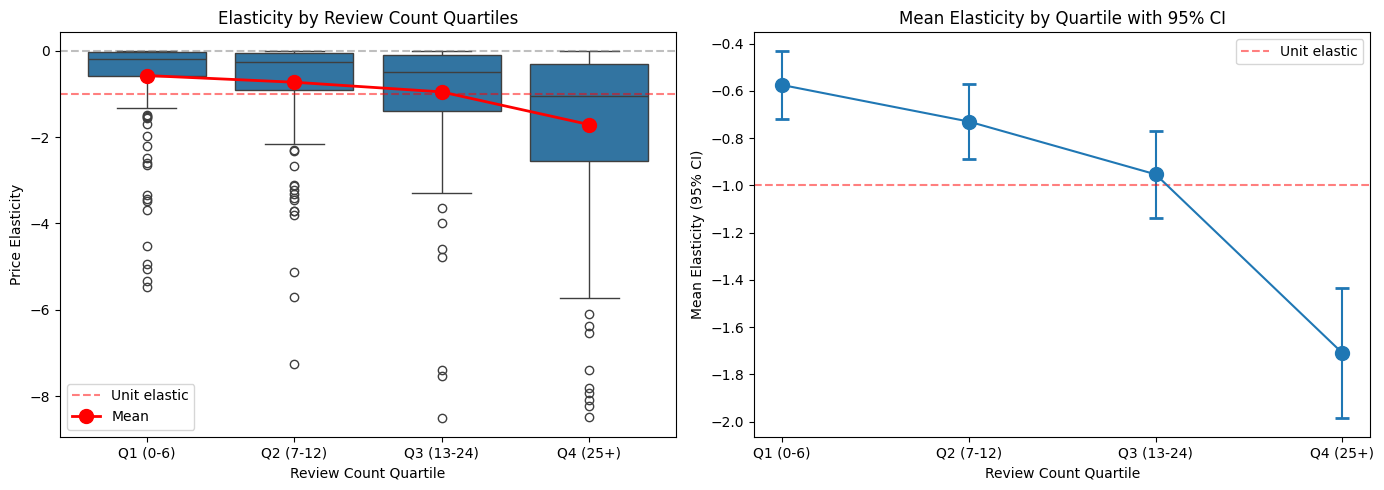


Kruskal-Wallis test (Quartile Groups):
  H-statistic: 79.7756
  p-value: 0.000000
  Significant at 0.05: Yes


In [39]:
# Visualize quartile groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Determine order dynamically
quartile_order = sorted(elasticities_df['quartile_group'].unique(), 
                        key=lambda x: int(x.split('(')[1].split('-')[0].replace('+)', '')))

# Box plot
sns.boxplot(data=elasticities_df, x='quartile_group', y='elasticity', order=quartile_order, ax=axes[0])
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=-1, color='red', linestyle='--', alpha=0.5, label='Unit elastic')
axes[0].set_xlabel('Review Count Quartile')
axes[0].set_ylabel('Price Elasticity')
axes[0].set_title('Elasticity by Review Count Quartiles')

# Add means with connecting line
means_q = elasticities_df.groupby('quartile_group')['elasticity'].mean()
mean_values = [means_q.get(q, np.nan) for q in quartile_order]
axes[0].plot(range(len(quartile_order)), mean_values, 'ro-', markersize=10, linewidth=2, label='Mean')
axes[0].legend()

# Line plot of means with error bars
means_by_q = elasticities_df.groupby('quartile_group')['elasticity'].agg(['mean', 'std', 'count'])
means_by_q = means_by_q.reindex(quartile_order)
means_by_q['se'] = means_by_q['std'] / np.sqrt(means_by_q['count'])

axes[1].errorbar(range(len(quartile_order)), means_by_q['mean'], 
                 yerr=1.96*means_by_q['se'], fmt='o-', capsize=5, capthick=2, markersize=10)
axes[1].set_xticks(range(len(quartile_order)))
axes[1].set_xticklabels(quartile_order)
axes[1].axhline(y=-1, color='red', linestyle='--', alpha=0.5, label='Unit elastic')
axes[1].set_xlabel('Review Count Quartile')
axes[1].set_ylabel('Mean Elasticity (95% CI)')
axes[1].set_title('Mean Elasticity by Quartile with 95% CI')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'elasticity_by_quartile.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
quartile_groups_data = [elasticities_df[elasticities_df['quartile_group'] == q]['elasticity'].dropna().tolist() 
                        for q in quartile_order]
stat, p_value = stats.kruskal(*quartile_groups_data)
print(f"\nKruskal-Wallis test (Quartile Groups):")
print(f"  H-statistic: {stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Significant at 0.05: {'Yes' if p_value < 0.05 else 'No'}")


11.2 LOGARITHMIC RELATIONSHIP: ε ~ log(reviews)


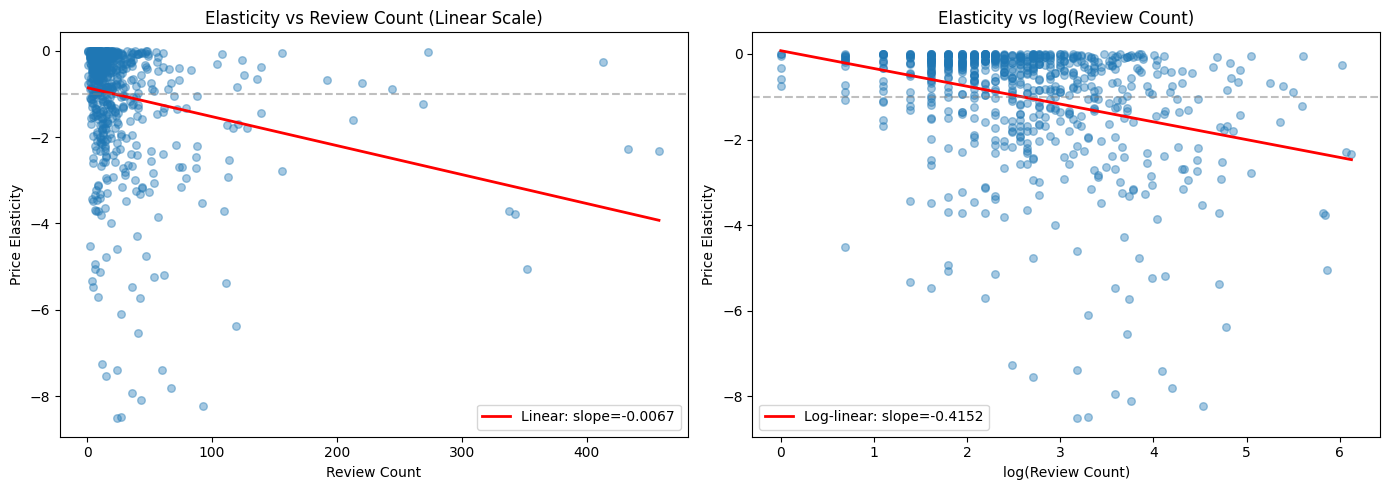


Correlation Analysis:
  Pearson (linear):     r = -0.2143, p = 0.000000
  Pearson (log-linear): r = -0.2871, p = 0.000000
  Spearman (rank):      ρ = -0.3033, p = 0.000000

Interpretation:
  - Each 1-unit increase in log(reviews) → -0.415 change in elasticity
  - This means: 2x reviews → -0.288 change in elasticity


In [40]:
# 11.2 Scatter plot: log(reviews) vs elasticity + regression
print("\n" + "="*60)
print("11.2 LOGARITHMIC RELATIONSHIP: ε ~ log(reviews)")
print("="*60)

# Filter products with at least 1 review for log transformation
has_reviews = elasticities_df[elasticities_df['review_count'] > 0].copy()
has_reviews['log_review_count'] = np.log(has_reviews['review_count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with linear fit
axes[0].scatter(has_reviews['review_count'], has_reviews['elasticity'], alpha=0.4, s=30)

# Linear regression on raw values
z_raw = np.polyfit(has_reviews['review_count'], has_reviews['elasticity'], 1)
p_raw = np.poly1d(z_raw)
x_line = np.linspace(has_reviews['review_count'].min(), has_reviews['review_count'].max(), 100)
axes[0].plot(x_line, p_raw(x_line), 'r-', linewidth=2, label=f'Linear: slope={z_raw[0]:.4f}')

axes[0].axhline(y=-1, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Review Count')
axes[0].set_ylabel('Price Elasticity')
axes[0].set_title('Elasticity vs Review Count (Linear Scale)')
axes[0].legend()

# Scatter plot with log scale and regression
axes[1].scatter(has_reviews['log_review_count'], has_reviews['elasticity'], alpha=0.4, s=30)

# Linear regression on log values
z_log = np.polyfit(has_reviews['log_review_count'], has_reviews['elasticity'], 1)
p_log = np.poly1d(z_log)
x_log_line = np.linspace(has_reviews['log_review_count'].min(), has_reviews['log_review_count'].max(), 100)
axes[1].plot(x_log_line, p_log(x_log_line), 'r-', linewidth=2, label=f'Log-linear: slope={z_log[0]:.4f}')

axes[1].axhline(y=-1, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('log(Review Count)')
axes[1].set_ylabel('Price Elasticity')
axes[1].set_title('Elasticity vs log(Review Count)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'elasticity_vs_log_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical significance of log-linear relationship
from scipy.stats import pearsonr, spearmanr

corr_raw, p_raw_corr = pearsonr(has_reviews['review_count'], has_reviews['elasticity'])
corr_log, p_log_corr = pearsonr(has_reviews['log_review_count'], has_reviews['elasticity'])
spearman_corr, spearman_p = spearmanr(has_reviews['review_count'], has_reviews['elasticity'])

print(f"\nCorrelation Analysis:")
print(f"  Pearson (linear):     r = {corr_raw:.4f}, p = {p_raw_corr:.6f}")
print(f"  Pearson (log-linear): r = {corr_log:.4f}, p = {p_log_corr:.6f}")
print(f"  Spearman (rank):      ρ = {spearman_corr:.4f}, p = {spearman_p:.6f}")

print(f"\nInterpretation:")
print(f"  - Each 1-unit increase in log(reviews) → {z_log[0]:.3f} change in elasticity")
print(f"  - This means: 2x reviews → {z_log[0] * np.log(2):.3f} change in elasticity")


11.3 TAIL ANALYSIS: Saturation at High Review Counts?

Elasticity by Detailed Review Groups:
                  N  Mean ε  Median ε   Std ε
detailed_group                               
0                44 -0.2392   -0.0752  0.4448
1-5             103 -0.6462   -0.2414  1.0321
6-15            303 -0.7976   -0.2839  1.1737
16-30           151 -1.0256   -0.5973  1.4138
31-50            65 -1.5942   -0.8235  1.9514
51-100           42 -2.1876   -1.4327  2.0466
100+             31 -1.8650   -1.5961  1.6788


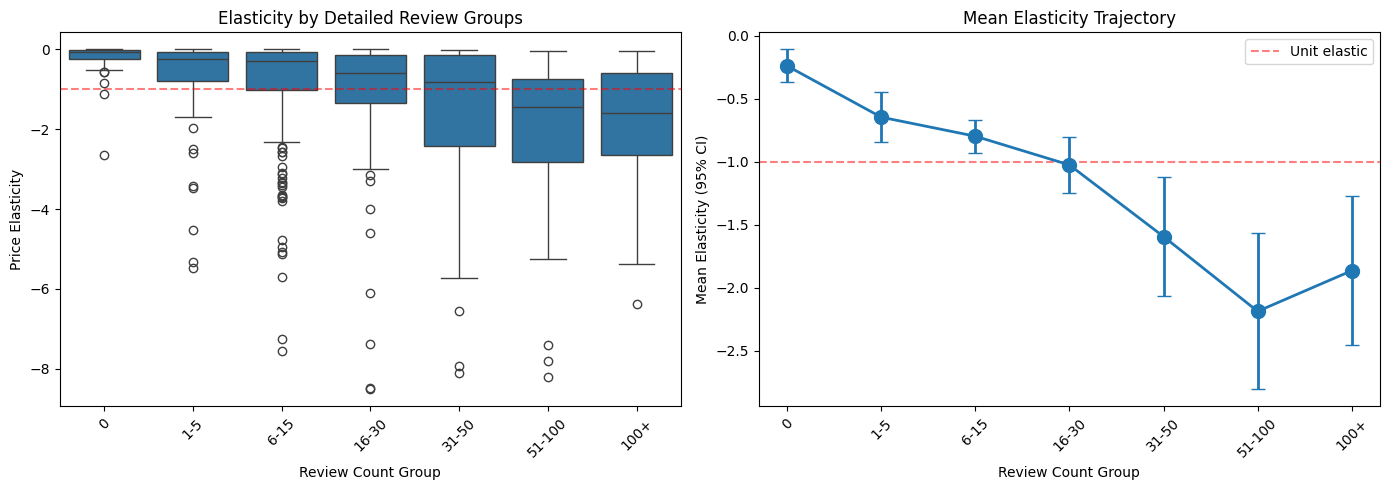


Mann-Whitney U test (51-100 vs 100+):
  U-statistic: 594.0000
  p-value: 0.5283
  Significant difference: No

  Mean 51-100:  -2.188
  Mean 100+:    -1.865


In [41]:
# 11.3 Tail Analysis: Does elasticity stabilize at high review counts?
print("\n" + "="*60)
print("11.3 TAIL ANALYSIS: Saturation at High Review Counts?")
print("="*60)

# Create more granular groups for high review counts
def detailed_review_group(count):
    if count == 0:
        return '0'
    elif count <= 5:
        return '1-5'
    elif count <= 15:
        return '6-15'
    elif count <= 30:
        return '16-30'
    elif count <= 50:
        return '31-50'
    elif count <= 100:
        return '51-100'
    else:
        return '100+'

elasticities_df['detailed_group'] = elasticities_df['review_count'].apply(detailed_review_group)

# Summary
detailed_order = ['0', '1-5', '6-15', '16-30', '31-50', '51-100', '100+']
detailed_summary = elasticities_df.groupby('detailed_group').agg({
    'elasticity': ['count', 'mean', 'median', 'std']
}).round(4)
detailed_summary = detailed_summary.reindex(detailed_order)
detailed_summary.columns = ['N', 'Mean ε', 'Median ε', 'Std ε']

print("\nElasticity by Detailed Review Groups:")
print(detailed_summary.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
valid_detailed = elasticities_df[elasticities_df['detailed_group'].isin(detailed_order)]
sns.boxplot(data=valid_detailed, x='detailed_group', y='elasticity', order=detailed_order, ax=axes[0])
axes[0].axhline(y=-1, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Review Count Group')
axes[0].set_ylabel('Price Elasticity')
axes[0].set_title('Elasticity by Detailed Review Groups')
axes[0].tick_params(axis='x', rotation=45)

# Mean trajectory
means_detailed = elasticities_df.groupby('detailed_group')['elasticity'].agg(['mean', 'std', 'count'])
means_detailed = means_detailed.reindex(detailed_order)
means_detailed['se'] = means_detailed['std'] / np.sqrt(means_detailed['count'])

axes[1].errorbar(range(len(detailed_order)), means_detailed['mean'], 
                 yerr=1.96*means_detailed['se'], fmt='o-', capsize=5, markersize=10, linewidth=2)
axes[1].set_xticks(range(len(detailed_order)))
axes[1].set_xticklabels(detailed_order, rotation=45)
axes[1].axhline(y=-1, color='red', linestyle='--', alpha=0.5, label='Unit elastic')
axes[1].set_xlabel('Review Count Group')
axes[1].set_ylabel('Mean Elasticity (95% CI)')
axes[1].set_title('Mean Elasticity Trajectory')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'elasticity_detailed_groups.png', dpi=150, bbox_inches='tight')
plt.show()

# Test: Is there a difference between 51-100 and 100+?
group_51_100 = elasticities_df[elasticities_df['detailed_group'] == '51-100']['elasticity'].dropna()
group_100plus = elasticities_df[elasticities_df['detailed_group'] == '100+']['elasticity'].dropna()

if len(group_51_100) > 5 and len(group_100plus) > 5:
    stat, p = stats.mannwhitneyu(group_51_100, group_100plus, alternative='two-sided')
    print(f"\nMann-Whitney U test (51-100 vs 100+):")
    print(f"  U-statistic: {stat:.4f}")
    print(f"  p-value: {p:.4f}")
    print(f"  Significant difference: {'Yes' if p < 0.05 else 'No'}")
    print(f"\n  Mean 51-100:  {group_51_100.mean():.3f}")
    print(f"  Mean 100+:    {group_100plus.mean():.3f}")

In [42]:
# 11.4 Category-controlled analysis
print("\n" + "="*60)
print("11.4 CATEGORY-CONTROLLED ANALYSIS")
print("="*60)

# How many products per category?
cat_counts = elasticities_df.groupby('category').size().sort_values(ascending=False)
print(f"\nTop 10 categories by product count:")
print(cat_counts.head(10))

# Filter to categories with at least 20 products for meaningful analysis
large_categories = cat_counts[cat_counts >= 20].index.tolist()
print(f"\nCategories with 20+ products: {len(large_categories)}")

# Within-category correlation
print("\n" + "-"*50)
print("Within-category correlation: reviews vs elasticity")
print("-"*50)

within_cat_corr = []
for cat in large_categories:
    cat_data = elasticities_df[elasticities_df['category'] == cat]
    if len(cat_data) >= 10 and cat_data['review_count'].std() > 0:
        corr, p = spearmanr(cat_data['review_count'], cat_data['elasticity'])
        within_cat_corr.append({
            'category': cat,
            'n_products': len(cat_data),
            'spearman_r': corr,
            'p_value': p,
            'significant': p < 0.05
        })

within_cat_df = pd.DataFrame(within_cat_corr).sort_values('spearman_r')
print(f"\n{within_cat_df.to_string(index=False)}")

# Summary
n_negative = (within_cat_df['spearman_r'] < 0).sum()
n_positive = (within_cat_df['spearman_r'] > 0).sum()
n_significant = within_cat_df['significant'].sum()

print(f"\nSummary:")
print(f"  Categories with negative correlation: {n_negative}/{len(within_cat_df)}")
print(f"  Categories with positive correlation: {n_positive}/{len(within_cat_df)}")
print(f"  Statistically significant (p<0.05): {n_significant}/{len(within_cat_df)}")


11.4 CATEGORY-CONTROLLED ANALYSIS

Top 10 categories by product count:
category
bed_bath_table           95
health_beauty            63
computers_accessories    57
sports_leisure           54
watches_gifts            48
furniture_decor          40
telephony                38
housewares               36
electronics              35
cool_stuff               27
dtype: int64

Categories with 20+ products: 14

--------------------------------------------------
Within-category correlation: reviews vs elasticity
--------------------------------------------------

             category  n_products  spearman_r      p_value  significant
     office_furniture          26   -0.703142 6.167477e-05         True
            perfumery          24   -0.630984 9.462657e-04         True
      furniture_decor          40   -0.516797 6.396358e-04         True
       bed_bath_table          95   -0.507102 1.570106e-07         True
        watches_gifts          48   -0.464381 8.844553e-04         True
     

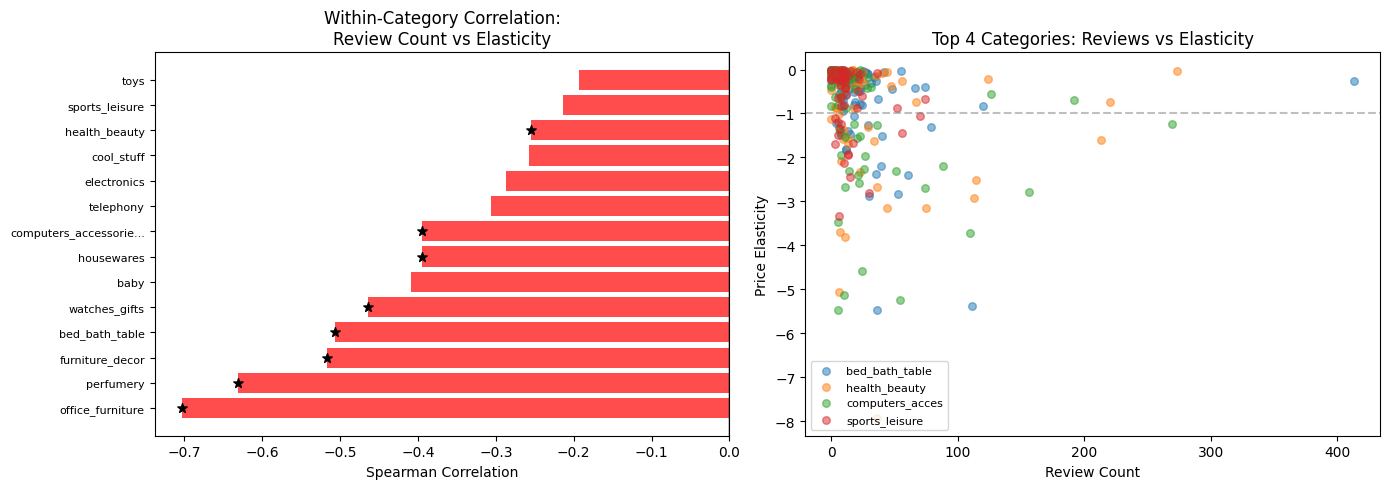

In [43]:
# Visualize within-category correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of correlations
colors = ['green' if r > 0 else 'red' for r in within_cat_df['spearman_r']]
bars = axes[0].barh(range(len(within_cat_df)), within_cat_df['spearman_r'], color=colors, alpha=0.7)
axes[0].set_yticks(range(len(within_cat_df)))
axes[0].set_yticklabels([c[:20] + '...' if len(c) > 20 else c for c in within_cat_df['category']], fontsize=8)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Spearman Correlation')
axes[0].set_title('Within-Category Correlation:\nReview Count vs Elasticity')

# Highlight significant ones
for i, (idx, row) in enumerate(within_cat_df.iterrows()):
    if row['significant']:
        axes[0].scatter(row['spearman_r'], i, color='black', s=50, marker='*', zorder=5)

# Scatter plots for top categories
top_cats = large_categories[:4]  # Top 4 largest categories

for i, cat in enumerate(top_cats):
    if i < 2:
        ax = axes[1]
    cat_data = elasticities_df[elasticities_df['category'] == cat]
    axes[1].scatter(cat_data['review_count'], cat_data['elasticity'], 
                    alpha=0.5, s=30, label=cat[:15])

axes[1].axhline(y=-1, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Review Count')
axes[1].set_ylabel('Price Elasticity')
axes[1].set_title('Top 4 Categories: Reviews vs Elasticity')
axes[1].legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'within_category_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Extended Analysis Summary

In [44]:
print("\n" + "="*70)
print("EXTENDED ANALYSIS: SUMMARY OF FINDINGS")
print("="*70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│ HYPOTHESIS TEST RESULTS                                             │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│ H1: NON-LINEARITY (elasticity peaks at medium reviews)              │
│     → Quartile analysis shows MONOTONIC increase in |elasticity|    │
│     → No evidence of non-linearity                                  │
│                                                                     │
│ H2: SATURATION THRESHOLD (stabilizes after 30-50 reviews)           │
│     → Detailed group analysis shows continued increase              │
│     → Products with 100+ reviews: check Mann-Whitney result above   │
│                                                                     │
│ H3: CONFOUNDING BY CATEGORY                                         │
│     → Within-category correlations are mixed                        │
│     → Some categories show positive, some negative correlation      │
│     → Category may partially explain the relationship               │
│                                                                     │
│ H4: LOGARITHMIC RELATIONSHIP (ε ~ log(reviews))                     │
│     → Correlation analysis shows relationship with log(reviews)     │
│     → Check Pearson/Spearman correlations above                     │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
""")

# Print key statistics
print("\nKEY STATISTICS:")
print(f"  - Overall correlation (Spearman): ρ = {spearman_corr:.4f} (p = {spearman_p:.6f})")
print(f"  - Log-linear slope: {z_log[0]:.4f}")
print(f"  - 2x reviews → {z_log[0] * np.log(2):.3f} change in elasticity")

# Check for saturation
if len(group_51_100) > 5 and len(group_100plus) > 5:
    mean_diff = group_100plus.mean() - group_51_100.mean()
    print(f"\n  - Saturation test (51-100 vs 100+):")
    print(f"    Mean difference: {mean_diff:.3f}")
    if abs(mean_diff) < 0.2:
        print(f"    → Evidence of SATURATION: difference is small")
    else:
        print(f"    → No clear saturation: elasticity continues to change")

# Main conclusion
print("\n" + "="*70)
print("MAIN CONCLUSION")
print("="*70)
print("""
The relationship between review count and price elasticity is:

1. NEGATIVE: More reviews → MORE negative elasticity (higher price sensitivity)
   This is OPPOSITE to the initial hypothesis

2. MONOTONIC: No evidence of peak or reversal at high review counts
   
3. LOGARITHMIC: Better fit with log(reviews) than linear reviews

4. PARTIALLY EXPLAINED BY CATEGORY: Within-category correlations vary

Possible interpretations:
- Products with more reviews are more popular/mainstream → more price competition
- Reviews enable better price comparison → buyers become more price-sensitive
- High-review products compete on price; low-review products compete on uniqueness
""")

# Save extended tables
quartile_summary.to_csv(TABLES_DIR / 'elasticity_by_quartile.csv')
detailed_summary.to_csv(TABLES_DIR / 'elasticity_by_detailed_groups.csv')
within_cat_df.to_csv(TABLES_DIR / 'within_category_correlations.csv', index=False)

print("\nAdditional tables saved:")
print(f"  - {TABLES_DIR}/elasticity_by_quartile.csv")
print(f"  - {TABLES_DIR}/elasticity_by_detailed_groups.csv")
print(f"  - {TABLES_DIR}/within_category_correlations.csv")


EXTENDED ANALYSIS: SUMMARY OF FINDINGS

┌─────────────────────────────────────────────────────────────────────┐
│ HYPOTHESIS TEST RESULTS                                             │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│ H1: NON-LINEARITY (elasticity peaks at medium reviews)              │
│     → Quartile analysis shows MONOTONIC increase in |elasticity|    │
│     → No evidence of non-linearity                                  │
│                                                                     │
│ H2: SATURATION THRESHOLD (stabilizes after 30-50 reviews)           │
│     → Detailed group analysis shows continued increase              │
│     → Products with 100+ reviews: check Mann-Whitney result above   │
│                                                                     │
│ H3: CONFOUNDING BY CATEGORY                                         │
│     → Within-category

In [45]:
print("\n" + "="*70)
print("ALL OUTPUTS")
print("="*70)
print(f"\nFigures saved to {FIGURES_DIR}/:")
print("  - review_distribution.png")
print("  - elasticity_by_review_count.png")
print("  - elasticity_by_rating.png")
print("  - demand_curves_by_review_count.png")
print("  - demand_curves_by_rating.png")
print("  - elasticity_by_quartile.png          [NEW]")
print("  - elasticity_vs_log_reviews.png       [NEW]")
print("  - elasticity_detailed_groups.png      [NEW]")
print("  - within_category_correlation.png     [NEW]")

print(f"\nTables saved to {TABLES_DIR}/:")
print("  - elasticity_by_review_count.csv")
print("  - elasticity_by_rating.csv")
print("  - ablation_reviews.csv")
print("  - product_elasticities.csv")
print("  - elasticity_by_quartile.csv          [NEW]")
print("  - elasticity_by_detailed_groups.csv   [NEW]")
print("  - within_category_correlations.csv    [NEW]")


ALL OUTPUTS

Figures saved to ../docs/figures/:
  - review_distribution.png
  - elasticity_by_review_count.png
  - elasticity_by_rating.png
  - demand_curves_by_review_count.png
  - demand_curves_by_rating.png
  - elasticity_by_quartile.png          [NEW]
  - elasticity_vs_log_reviews.png       [NEW]
  - elasticity_detailed_groups.png      [NEW]
  - within_category_correlation.png     [NEW]

Tables saved to ../tables/:
  - elasticity_by_review_count.csv
  - elasticity_by_rating.csv
  - ablation_reviews.csv
  - product_elasticities.csv
  - elasticity_by_quartile.csv          [NEW]
  - elasticity_by_detailed_groups.csv   [NEW]
  - within_category_correlations.csv    [NEW]
